<a href="https://colab.research.google.com/github/antonellagambarte/deep-learning--CEIA/blob/main/GAMBARTE_ANTONELLA_NEREA_DL_TP2_Co21.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import gdown
import zipfile
import os

url = "https://drive.google.com/uc?id=1pGsz3NFVHOfDpFG3jvpuM4NtpDCv757Z"
output = "archivo.zip"

gdown.download(url, output, quiet=False)

destino = "datos_zip"
os.makedirs(destino, exist_ok=True)

with zipfile.ZipFile(output, 'r') as zip_ref:
    zip_ref.extractall(destino)

import time
from collections import Counter
import random
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split, Dataset
from torchvision import transforms, datasets
from sklearn.metrics import classification_report, confusion_matrix, f1_score, accuracy_score
import itertools
from tqdm import tqdm
import seaborn as sns

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Device:", device)
INFER_DIR          = 'drive/MyDrive/emociones_nuevo'
OUTPUT_MODEL       = 'drive/MyDrive/best_emotion_model.pth'
DATASET_ROOT_TRAIN = '/content/datos_zip/dataset_emociones/train'
DATASET_ROOT_VAL   = '/content/datos_zip/dataset_emociones/validation'

Downloading...
From (original): https://drive.google.com/uc?id=1pGsz3NFVHOfDpFG3jvpuM4NtpDCv757Z
From (redirected): https://drive.google.com/uc?id=1pGsz3NFVHOfDpFG3jvpuM4NtpDCv757Z&confirm=t&uuid=a4679c91-d527-4900-b2d2-63db292240ec
To: /content/archivo.zip
100%|██████████| 40.0M/40.0M [00:00<00:00, 156MB/s]


Device: cuda


### **1. Preprocesamiento de Datos**

Antes de entrenar el modelo, se realizó un análisis de las características del conjunto de datos para aplicar un preprocesamiento adecuado para el problema de clasificación de emociones.

Las imágenes fueron redimensionadas a 96x96 píxeles, se convirtieron a escala de grises ya que el color no aporta información significativa para el reconocimiento de emociones. De todas formas se realizaron pruebas utilizando las imágenes en color, pero no se observaron mejoras en los resultados. Por el contrario, en algunos casos, se introdujo ruido innecesario que perjudicó la generalización.

En cuanto a Data Augmentation, se probaron técnicas básicas de data augmentation como rotación, traslación y flips, pero no se observaron mejoras significativas en la validación. Incluso, en algunos casos, el modelo presentaba peor desempeño.



In [ ]:
IMG_SIZE = 96
CHANNELS = 1

train_transforms = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.5], [0.5]),
])

val_transforms = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.5], [0.5]),
])


In [ ]:

train_dataset = datasets.ImageFolder(DATASET_ROOT_TRAIN, transform=train_transforms)
val_dataset   = datasets.ImageFolder(DATASET_ROOT_VAL, transform=val_transforms)

class_names = train_dataset.classes
num_classes = len(class_names)
print("Clases detectadas:", class_names)
print("Num clases:", num_classes)
print("Train size:", len(train_dataset), "Val size:", len(val_dataset))

# conteo por clase en train
labels_train = [s[1] for s in train_dataset.samples]
counts = Counter(labels_train)
counts_named = {class_names[i]: counts[i] for i in range(num_classes)}
print("Conteos (train):", counts_named)

Clases detectadas: ['alegria', 'disgusto', 'enojo', 'miedo', 'seriedad', 'sorpresa', 'tristeza']
Num clases: 7
Train size: 12271 Val size: 3068
Conteos (train): {'alegria': 4772, 'disgusto': 717, 'enojo': 705, 'miedo': 281, 'seriedad': 2524, 'sorpresa': 1290, 'tristeza': 1982}


In [ ]:
BATCH_SIZE = 64
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, pin_memory=True)
val_loader   = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, pin_memory=True)

### **2. Construcción y entrenamiento del Modelo CNN**

Para resolver el problema de clasificación de emociones en imágenes faciales, se diseñó una arquitectura de red neuronal convolucional con un enfoque equilibrado entre capacidad de aprendizaje y eficiencia computacional. Las decisiones arquitectónicas se tomaron considerando las características particulares del dataset, como el tamaño reducido de las imágenes (96x96 píxeles) y su formato en escala de grises.

La red usa 3 bloques convolucionales. Cada bloque duplica la cantidad de filtros, incrementando la capacidad de la red para capturar patrones complejos. También se agrega un Dropout2D con p=0.2, para evitar overfitting.

Se probó incluir una cuarta capa convolucional, pero no se observaron mejoras en la validación, por lo que se optó por mantener 3 bloques para reducir complejidad.

**Elección del número de filtros**

Se incrementa progresivamente el número de canales de salida (de 64 a 128 y luego a 256).

Se realizaron pruebas con otras configuraciones de tamaño de capas (por ejemplo, incorporando la cuarta capa convolucional, o ajustando el número de filtros), pero los mejores resultados de validación se obtuvieron con esta estructura de tres bloques y la progresión 64 → 128 → 256.

**Tamaño del kernel (k=3)**

Se utilizó un kernel de tamaño 3x3. Este tamaño permite capturar patrones locales con suficiente precisión sin incrementar excesivamente los parámetros del modelo.
Se realizaron pruebas con kernels más grandes (como 5x5), pero no se observaron mejoras significativas en el desempeño.

**Padding 'same'**

Se estableció el padding='same' para mantener las dimensiones espaciales constantes después de cada convolución.

**Stride = 1**

Se eligió un stride=1 para conservar la resolución máxima después de la convolución. Esto esirvió para preservar información como gestos sutiles que pueden marcar la diferencia entre clases.

**MaxPooling (pk=2)**

Cada bloque finaliza con una operación de MaxPool2D(kernel_size=2), que reduce las dimensiones espaciales a la mitad con el fin de disminuir la cantidad de parámetros.

-- --------------------------------

Una vez extraídas las características espaciales de las imágenes a través de las capas convolucionales, se incorporó una sección de capas fully connected que cumple la función de clasificador final. Durante la experimentación, se probó una versión alternativa a la que se encuentra en el código utilizando una capa de pooling adaptativo antes de la capa lineal. Sin embargo, los resultados de validación y pruebas mostraron que esta variante tenía menor capacidad de generalización.

In [ ]:
def conv_block(c_in, c_out, k=3, p='same', s=1, pk=2):
    if p == 'same':
        padding = k // 2
    else:
        padding = 0
    return nn.Sequential(
        nn.Conv2d(c_in, c_out, kernel_size=k, stride=s, padding=padding), # convolución 2D
        nn.BatchNorm2d(c_out), # normalización por batch
        nn.ReLU(inplace=True), # activación no lineal
        nn.MaxPool2d(kernel_size=pk) # reduce tamaño espacial
    )

class CNN(nn.Module):
    def __init__(self, n_channels=1, n_outputs=7):
        super().__init__()
        self.conv1 = conv_block(c_in=n_channels, c_out=64, k=3, p='same', s=1, pk=2)
        self.conv1_out = None
        self.drop = nn.Dropout2d(p=0.2)
        self.conv2 = conv_block(c_in=64, c_out=128, k=3, p='same', s=1, pk=2)
        self.conv2_out = None
        self.conv3 = conv_block(c_in=128, c_out=256, k=3, p='same', s=1, pk=2)
        self.conv3_out = None

        with torch.no_grad():
            dummy = torch.zeros(1, n_channels, 96, 96)
            out = self.drop(self.conv1(dummy))
            out = self.drop(self.conv2(out))
            out = self.drop(self.conv3(out))

            self.flatten_dim = out.view(1, -1).shape[1]


        self.fc = nn.Sequential(
            nn.Linear(self.flatten_dim, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(inplace=True),
            nn.Dropout(p=0.2),

            nn.Linear(512, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(inplace=True),
            nn.Dropout(p=0.2),

            nn.Linear(128, n_outputs)
        )

        print('--- CNN creada ---')
        print('Flatten dim:', self.flatten_dim)
        pytorch_total_params = sum(p.numel() for p in self.parameters() if p.requires_grad)
        print('Parámetros entrenables:', pytorch_total_params)

    def forward(self, x):
      self.conv1_out = self.drop(self.conv1(x))
      self.conv2_out = self.drop(self.conv2(self.conv1_out))
      self.conv3_out = self.drop(self.conv3(self.conv2_out))
      y = self.conv3_out.flatten(start_dim=1)
      y = self.fc(y)
      return y


model = CNN(n_channels=CHANNELS, n_outputs=num_classes).to(device)
print(next(model.parameters()).device)

--- CNN creada ---
Flatten dim: 36864
Parámetros entrenables: 19313287
cuda:0


El dataset presenta un claro desbalance entre clases, con ciertas emociones representadas con mucha más frecuencia que otras. Para contrarrestar este efecto y evitar que el modelo se sesgue hacia las clases mayoritarias, se calcularon pesos inversamente proporcionales a la frecuencia de cada clase.

Estos pesos fueron normalizados y utilizados como argumento en la función de pérdida CrossEntropyLoss.

Además, se utilizó el optimizador Adam con una tasa de aprendizaje inicial de 0.001, y se incorporó un scheduler ReduceLROnPlateau, que reduce automáticamente la tasa de aprendizaje si no se observa mejora en la función de pérdida durante 3 épocas consecutivas. Este mecanismo permite adaptarse dinámicamente al progreso del entrenamiento y prevenir estancamientos.

Se realizaron pruebas comparando el entrenamiento con y sin el uso del scheduler, y los resultados obtenidos mostraron una mejor convergencia y mayor estabilidad al incluirlo. Esto se tradujo en una mejor capacidad de generalización del modelo sobre el conjunto de validación.

In [ ]:
label_counts = np.array([counts[i] for i in range(num_classes)])
print("label_counts:", label_counts)

class_weights = 1.0 / label_counts
class_weights = class_weights / class_weights.sum() * num_classes
print("class_weights (normalizadas):", np.round(class_weights,3))

class_weights_tensor = torch.tensor(class_weights, dtype=torch.float).to(device)
criterion = nn.CrossEntropyLoss(weight=class_weights_tensor,label_smoothing=0.1)

optimizer = optim.Adam(model.parameters(), lr=0.001)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)



label_counts: [4772  717  705  281 2524 1290 1982]
class_weights (normalizadas): [0.178 1.182 1.202 3.017 0.336 0.657 0.428]


In [ ]:
def train_one_epoch(model, loader, optimizer, criterion):
    model.train()
    running_loss = 0.0
    all_preds, all_labels = [], []
    for imgs, labels in loader:
        imgs = imgs.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(imgs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * imgs.size(0)

        preds = outputs.argmax(dim=1)
        all_preds.append(preds)
        all_labels.append(labels)


    all_preds = torch.cat(all_preds).cpu().numpy()
    all_labels = torch.cat(all_labels).cpu().numpy()

    epoch_loss = running_loss / len(loader.dataset)
    acc = accuracy_score(all_labels, all_preds)
    f1 = f1_score(all_labels, all_preds, average='macro')

    return epoch_loss, acc, f1

def eval_model(model, loader, criterion):
    model.eval()
    running_loss = 0.0
    all_preds, all_labels = [], []
    with torch.no_grad():
        for imgs, labels in loader:
            imgs = imgs.to(device)
            labels = labels.to(device)
            outputs = model(imgs)
            loss = criterion(outputs, labels)
            running_loss += loss.item() * imgs.size(0)

            preds = outputs.argmax(dim=1)
            all_preds.append(preds)
            all_labels.append(labels)


    all_preds = torch.cat(all_preds).cpu().numpy()
    all_labels = torch.cat(all_labels).cpu().numpy()

    epoch_loss = running_loss / len(loader.dataset)
    acc = accuracy_score(all_labels, all_preds)
    f1 = f1_score(all_labels, all_preds, average='macro')

    return epoch_loss, acc, f1, all_labels, all_preds

In [ ]:
# Ejecuta entrenamiento
EPOCHS = 20
history = {'train_loss':[], 'val_loss':[], 'train_acc':[], 'val_acc':[], 'train_f1':[], 'val_f1':[]}
best_val_loss = np.inf
best_val_f1 = 0

for ep in range(EPOCHS):
    t0 = time.time()
    train_loss, train_acc, train_f1 = train_one_epoch(model, train_loader, optimizer, criterion)
    val_loss, val_acc, val_f1, _, _ = eval_model(model, val_loader, criterion)
    scheduler.step(val_loss)

    history['train_loss'].append(train_loss); history['val_loss'].append(val_loss)
    history['train_acc'].append(train_acc); history['val_acc'].append(val_acc)
    history['train_f1'].append(train_f1); history['val_f1'].append(val_f1)

    print(f"Ep {ep+1}/{EPOCHS}  train_loss {train_loss:.4f} acc {train_acc:.4f} f1 {train_f1:.4f}  |  val_loss {val_loss:.4f} acc {val_acc:.4f} f1 {val_f1:.4f}  (t={(time.time()-t0):.1f}s)")
    if val_f1 > best_val_f1:
      best_val_f1 = val_f1
      torch.save(model.state_dict(), OUTPUT_MODEL)
      print("  -> Guardado mejor modelo (según F1)")


Ep 1/20  train_loss 1.9604 acc 0.3298 f1 0.2763  |  val_loss 2.0166 acc 0.5140 f1 0.4400  (t=13.1s)
  -> Guardado mejor modelo (según F1)
Ep 2/20  train_loss 1.6589 acc 0.5370 f1 0.4560  |  val_loss 1.8586 acc 0.6147 f1 0.5308  (t=13.2s)
  -> Guardado mejor modelo (según F1)
Ep 3/20  train_loss 1.5164 acc 0.6154 f1 0.5367  |  val_loss 1.8161 acc 0.6467 f1 0.5564  (t=13.2s)
  -> Guardado mejor modelo (según F1)
Ep 4/20  train_loss 1.4006 acc 0.6827 f1 0.6057  |  val_loss 1.7118 acc 0.7226 f1 0.6371  (t=13.0s)
  -> Guardado mejor modelo (según F1)
Ep 5/20  train_loss 1.2914 acc 0.7237 f1 0.6572  |  val_loss 1.7168 acc 0.7168 f1 0.6308  (t=12.9s)
Ep 6/20  train_loss 1.2127 acc 0.7642 f1 0.7037  |  val_loss 1.7101 acc 0.7213 f1 0.6381  (t=13.0s)
  -> Guardado mejor modelo (según F1)
Ep 7/20  train_loss 1.1421 acc 0.7981 f1 0.7452  |  val_loss 1.6895 acc 0.7474 f1 0.6475  (t=13.0s)
  -> Guardado mejor modelo (según F1)
Ep 8/20  train_loss 1.0818 acc 0.8289 f1 0.7836  |  val_loss 1.7035 acc 

### **3. Evaluación del Modelo**

A lo largo de 20 épocas de entrenamiento, se observaron las siguientes tendencias:

Loss:
Disminuyó consistentemente en el conjunto de entrenamiento, mientras que en validación se redujo en las primeras épocas y luego se estabilizó. Esto indica una buena convergencia inicial, con posible sobreajuste leve en las últimas épocas.

Accuracy:
Se incrementó de manera constante durante el entrenamiento, alcanzando valores cercanos al 100%. En validación, el crecimiento fue más moderado, estabilizándose cerca del 80% hacia el final, lo cual representa una buena capacidad de generalización.

F1 Score:
La evolución del F1 Score fue coherente con la accuracy, con un valor final de validación cercano al 70%. Dado que esta métrica pondera todas las clases por igual, es útil para reflejar el desempeño sobre clases menos representadas, donde el modelo mostró mayor dificultad.

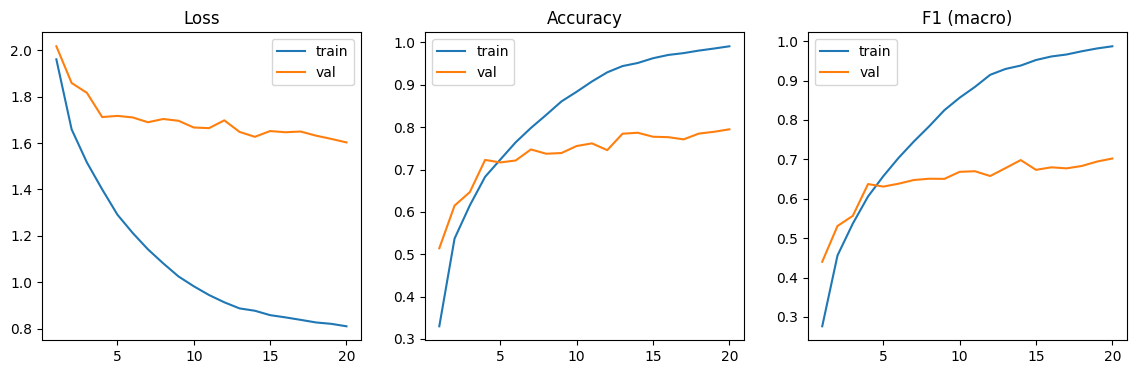

In [ ]:
# Plots: pérdida, accuracy, F1
epochs = range(1, len(history['train_loss'])+1)
plt.figure(figsize=(14,4))
plt.subplot(1,3,1)
plt.plot(epochs, history['train_loss'], label='train'); plt.plot(epochs, history['val_loss'], label='val'); plt.title("Loss"); plt.legend()
plt.subplot(1,3,2)
plt.plot(epochs, history['train_acc'], label='train'); plt.plot(epochs, history['val_acc'], label='val'); plt.title("Accuracy"); plt.legend()
plt.subplot(1,3,3)
plt.plot(epochs, history['train_f1'], label='train'); plt.plot(epochs, history['val_f1'], label='val'); plt.title("F1 (macro)"); plt.legend()
plt.show()


Validation -> loss: 1.6026  acc: 0.7950  f1: 0.7020

Classification report (validation):
              precision    recall  f1-score   support

     alegria     0.9411    0.8759    0.9073      1185
    disgusto     0.4938    0.5000    0.4969       160
       enojo     0.6906    0.7716    0.7289       162
       miedo     0.4471    0.5135    0.4780        74
    seriedad     0.7438    0.7985    0.7702       680
    sorpresa     0.7920    0.7872    0.7896       329
    tristeza     0.7417    0.7448    0.7432       478

    accuracy                         0.7950      3068
   macro avg     0.6929    0.7131    0.7020      3068
weighted avg     0.8018    0.7950    0.7976      3068

Confusion matrix (absolute):
 [[1038   19   13   18   47   16   34]
 [  13   80   14    1   28    3   21]
 [   6    9  125    4    6    9    3]
 [   2    3    6   38    4   14    7]
 [  20   31    7    3  543   23   53]
 [  12    1    7   12   32  259    6]
 [  12   19    9    9   70    3  356]]
Confusion matrix 

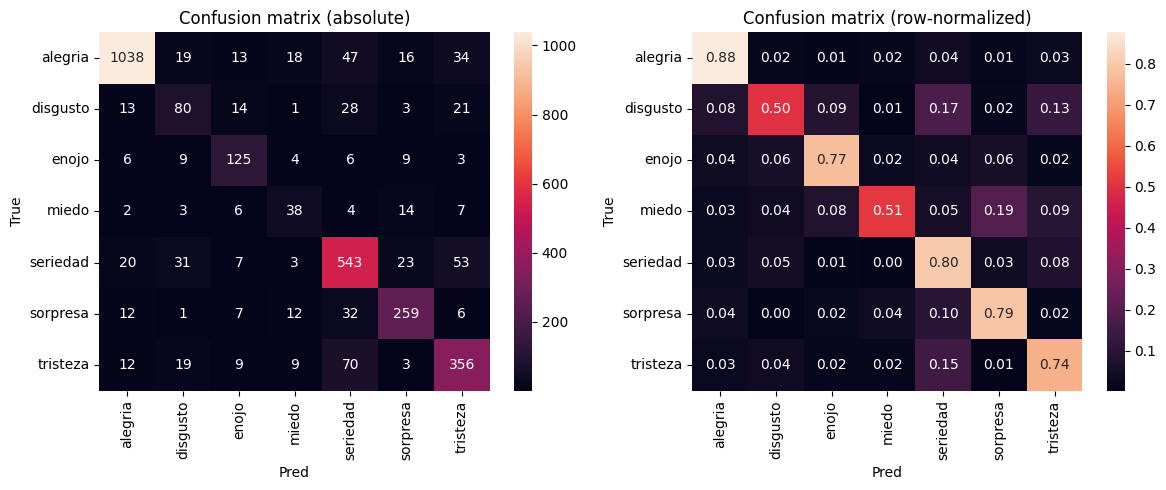

In [ ]:
# Evaluación final en validation: classification report y conf matrices

model.load_state_dict(torch.load(OUTPUT_MODEL))
val_loss, val_acc, val_f1, y_true, y_pred = eval_model(model, val_loader, criterion)
print(f"Validation -> loss: {val_loss:.4f}  acc: {val_acc:.4f}  f1: {val_f1:.4f}")

print("\nClassification report (validation):")
print(classification_report(y_true, y_pred, target_names=class_names, digits=4))

cm = confusion_matrix(y_true, y_pred)
cm_norm = cm.astype(float) / cm.sum(axis=1)[:,None]

print("Confusion matrix (absolute):\n", cm)
print("Confusion matrix (row-normalized):\n", np.round(cm_norm,3))

plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
sns.heatmap(cm, annot=True, fmt='d', xticklabels=class_names, yticklabels=class_names)
plt.title("Confusion matrix (absolute)"); plt.xlabel("Pred"); plt.ylabel("True")
plt.subplot(1,2,2)
sns.heatmap(cm_norm, annot=True, fmt='.2f', xticklabels=class_names, yticklabels=class_names)
plt.title("Confusion matrix (row-normalized)"); plt.xlabel("Pred"); plt.ylabel("True")
plt.tight_layout()
plt.show()


En general, el modelo clasifica correctamente una alta proporción de ejemplos de clases frecuentes como alegría (88%) y seriedad (80%), lo que es coherente con su mayor representación en el dataset.

Otras clases, como sorpresa y tristeza, también alcanzan valores razonables (79% y 74% respectivamente).

Las clases menos representadas o con patrones faciales más ambiguos, como disgusto (50%) y miedo (51%), muestran mayor confusión con otras emociones.

### **4. Prueba de Imágenes Nuevas**


=== Prueba con imágenes nuevas ===
Clases del modelo: ['alegria', 'disgusto', 'enojo', 'miedo', 'seriedad', 'sorpresa', 'tristeza']
Se encontraron 6 imágenes para inferencia.

Imagen: tristeza.png
Predicción: seriedad
  alegria: 0.010
  disgusto: 0.055
  enojo: 0.074
  miedo: 0.136
  seriedad: 0.612
  sorpresa: 0.108
  tristeza: 0.004


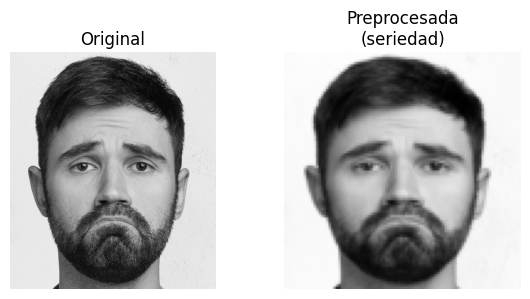


Imagen: enojo.png
Predicción: enojo
  alegria: 0.116
  disgusto: 0.037
  enojo: 0.301
  miedo: 0.209
  seriedad: 0.140
  sorpresa: 0.082
  tristeza: 0.115


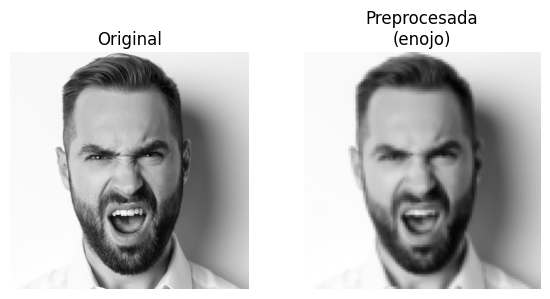


Imagen: sorpresa.png
Predicción: sorpresa
  alegria: 0.004
  disgusto: 0.048
  enojo: 0.089
  miedo: 0.071
  seriedad: 0.005
  sorpresa: 0.769
  tristeza: 0.014


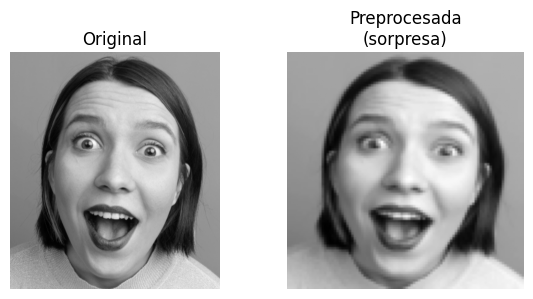


Imagen: miedo.png
Predicción: miedo
  alegria: 0.207
  disgusto: 0.047
  enojo: 0.244
  miedo: 0.334
  seriedad: 0.067
  sorpresa: 0.030
  tristeza: 0.072


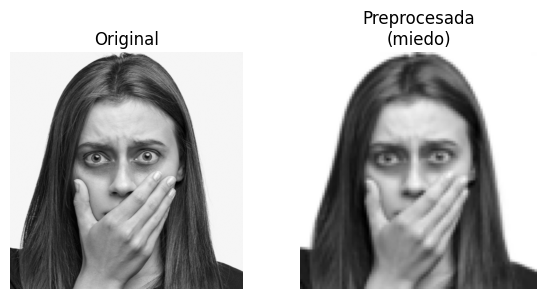


Imagen: seriedad.png
Predicción: tristeza
  alegria: 0.014
  disgusto: 0.040
  enojo: 0.170
  miedo: 0.104
  seriedad: 0.056
  sorpresa: 0.023
  tristeza: 0.592


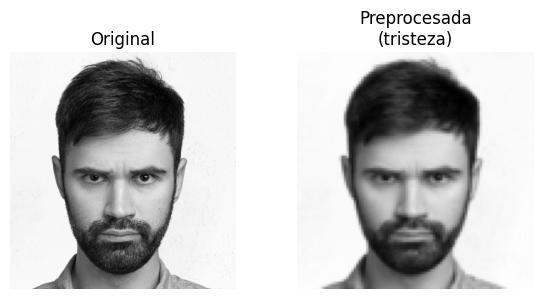


Imagen: alegria.png
Predicción: alegria
  alegria: 0.437
  disgusto: 0.068
  enojo: 0.079
  miedo: 0.110
  seriedad: 0.011
  sorpresa: 0.226
  tristeza: 0.070


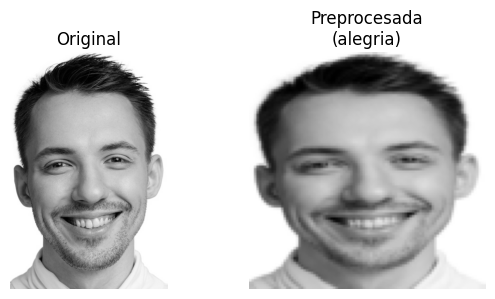

In [ ]:
print("\n=== Prueba con imágenes nuevas ===")

model.load_state_dict(torch.load(OUTPUT_MODEL, map_location=device))
model.eval()
infer_transform = val_transforms
print("Clases del modelo:", class_names)

image_paths = [os.path.join(INFER_DIR, f) for f in os.listdir(INFER_DIR)
               if f.lower().endswith(('.jpg', '.jpeg', '.png'))]

print(f"Se encontraron {len(image_paths)} imágenes para inferencia.")

for path in image_paths:
    img_orig = Image.open(path).convert('L')
    img_proc = infer_transform(img_orig)
    img_proc_batch = img_proc.unsqueeze(0).to(device)

    with torch.no_grad():
        outputs = model(img_proc_batch)
        probs = torch.softmax(outputs, dim=1).cpu().numpy()[0]
        pred_class = np.argmax(probs)
        pred_label = class_names[pred_class]

    print(f"\nImagen: {os.path.basename(path)}")
    print(f"Predicción: {pred_label}")
    for i, c in enumerate(class_names):
        print(f"  {c}: {probs[i]:.3f}")

    fig, axes = plt.subplots(1, 2, figsize=(6,3))
    axes[0].imshow(img_orig, cmap='gray')
    axes[0].set_title("Original")
    axes[0].axis("off")

    axes[1].imshow((img_proc.squeeze().numpy() * 0.5 + 0.5), cmap='gray')
    axes[1].set_title(f"Preprocesada\n({pred_label})")
    axes[1].axis("off")

    plt.tight_layout()
    plt.show()



De las pruebas realizadas sobre 6 imagenes nuevas se destaca lo siguiente:

- Predicciones acertadas: El modelo identificó correctamente las emociones de enojo, sorpresa, miedo y alegría, con probabilidades de 0.301, 0.769, 0.334 y 0.437 respectivamente.

- Predicciones con confusión: Para las imágenes etiquetadas como miedo, tristeza y seriedad, el modelo mostró confusión:
La imagen de miedo fue clasificada correctamente, pero con una probabilidad moderada (0.334) y una importante distribución de probabilidad en clases cercanas (enojo 0.244, alegría 0.207), lo que sugiere cierta incertidumbre.
La imagen de tristeza fue predicha como seriedad, con alta probabilidad (0.612). De manera similar, la imagen de seriedad fue clasificada como tristeza con probabilidad 0.592. Esta confusión puede deberse a que estas emociones pueden presentar características faciales similares, especialmente en imágenes nuevas y fuera del dataset original.

- Distribución de probabilidades: En general, el modelo asigna probabilidades distribuidas a varias clases en imágenes con emociones menos definidas o que podrían tener expresiones faciales similares. Quizas el modelo podría beneficiarse de un dataset más balanceado para estas emociones.

### **5. Prueba de Imágenes Nuevas con Pre-procesamiento Adicional**


=== Imagen: tristeza.png ===
Predicción: tristeza
  alegria: 0.000
  disgusto: 0.208
  enojo: 0.030
  miedo: 0.116
  seriedad: 0.026
  sorpresa: 0.079
  tristeza: 0.540


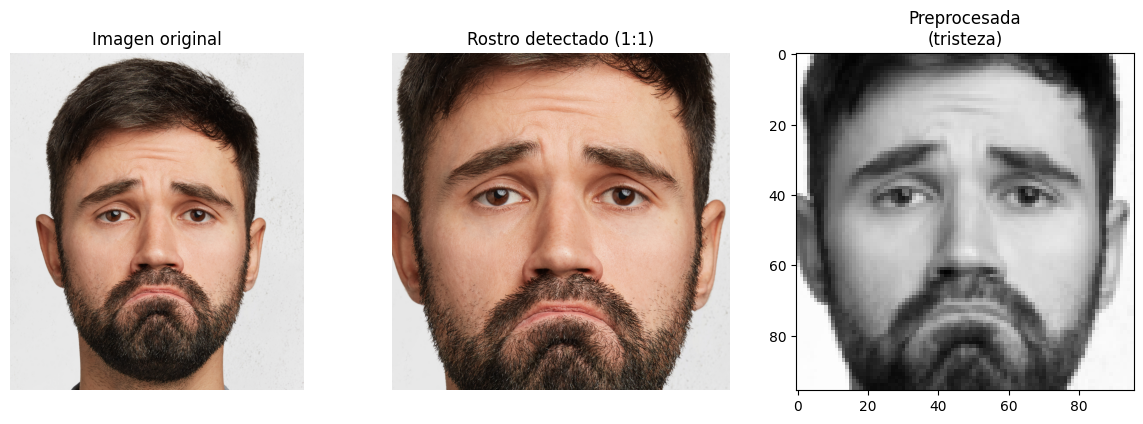


=== Imagen: enojo.png ===
Predicción: enojo
  alegria: 0.007
  disgusto: 0.016
  enojo: 0.847
  miedo: 0.059
  seriedad: 0.022
  sorpresa: 0.026
  tristeza: 0.024


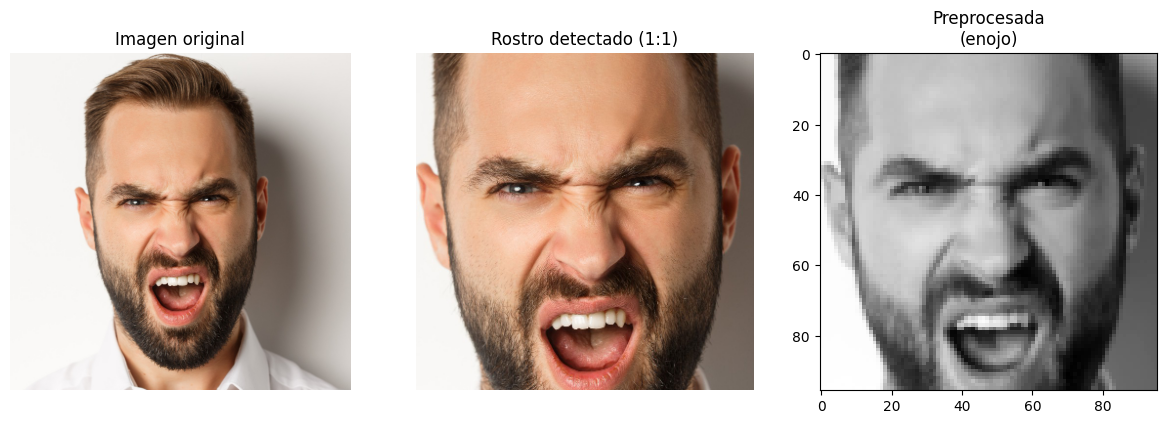


=== Imagen: sorpresa.png ===
Predicción: sorpresa
  alegria: 0.025
  disgusto: 0.076
  enojo: 0.049
  miedo: 0.150
  seriedad: 0.202
  sorpresa: 0.366
  tristeza: 0.131


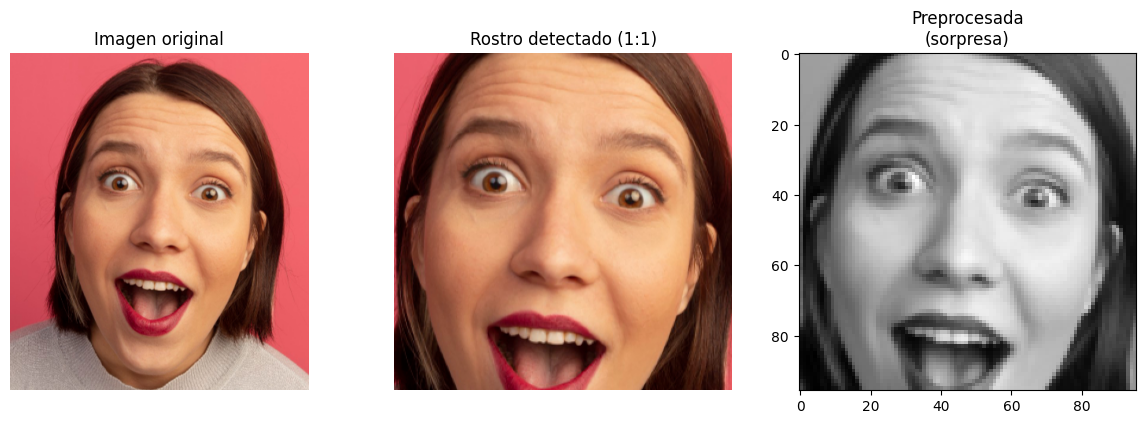


=== Imagen: miedo.png ===
Predicción: tristeza
  alegria: 0.195
  disgusto: 0.050
  enojo: 0.077
  miedo: 0.169
  seriedad: 0.008
  sorpresa: 0.192
  tristeza: 0.309


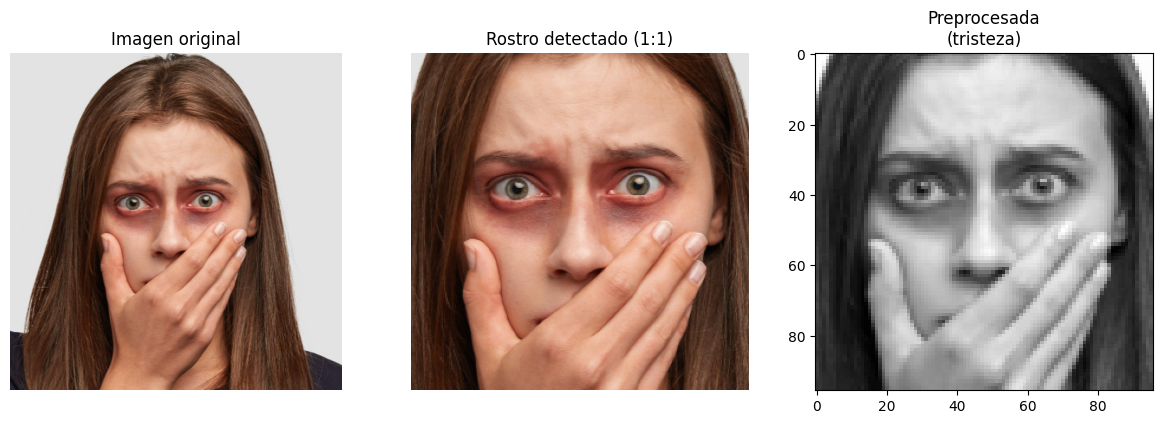


=== Imagen: seriedad.png ===
Predicción: seriedad
  alegria: 0.007
  disgusto: 0.140
  enojo: 0.109
  miedo: 0.213
  seriedad: 0.393
  sorpresa: 0.112
  tristeza: 0.027


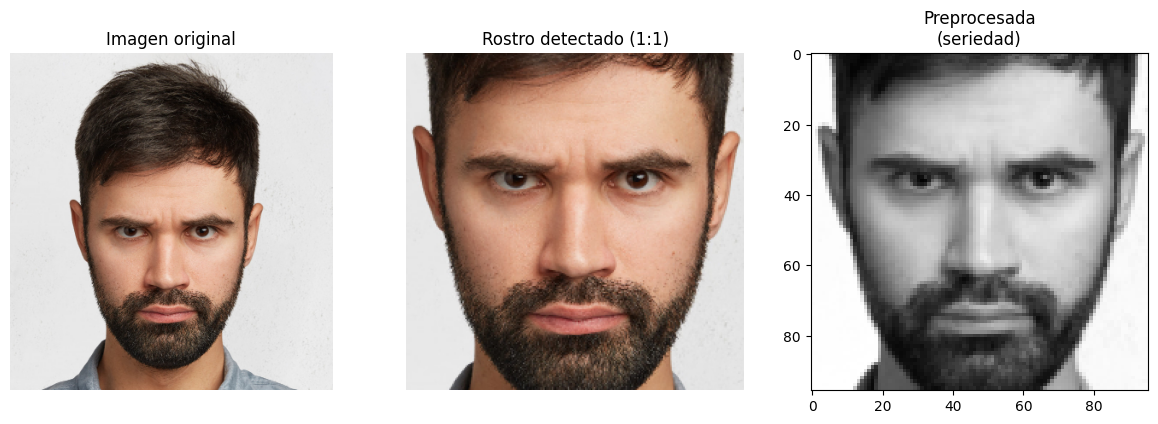


=== Imagen: alegria.png ===
Predicción: tristeza
  alegria: 0.071
  disgusto: 0.266
  enojo: 0.049
  miedo: 0.261
  seriedad: 0.005
  sorpresa: 0.072
  tristeza: 0.277


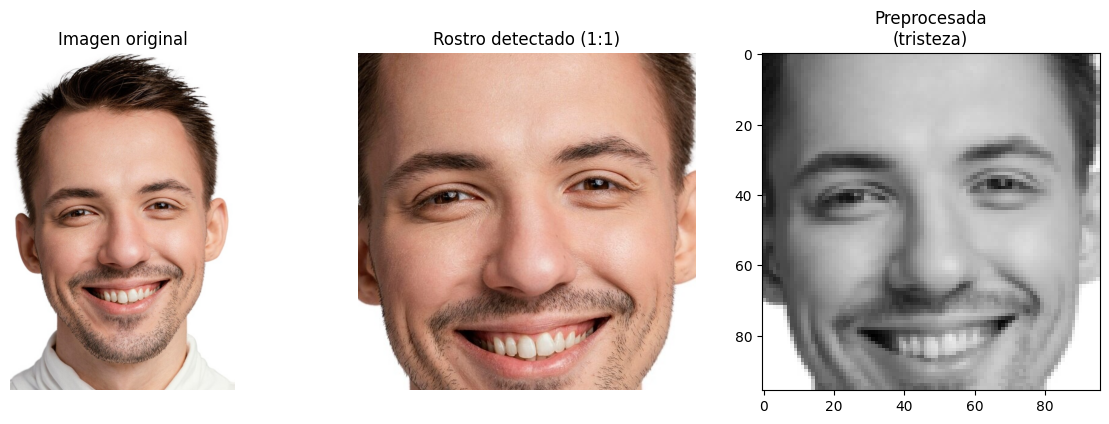

In [ ]:
import cv2
from torchvision.transforms.functional import to_pil_image

model.load_state_dict(torch.load(OUTPUT_MODEL, map_location=device))
model.eval()

face_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_frontalface_default.xml')

for path in image_paths:
    print(f"\n=== Imagen: {os.path.basename(path)} ===")

    image_bgr = cv2.imread(path)
    image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)
    gray = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2GRAY)

    faces = face_cascade.detectMultiScale(gray, scaleFactor=1.1, minNeighbors=6)

    image_with_box = image_rgb.copy()
    cropped_face_rgb = None

    if len(faces) > 0:
        (x, y, w, h) = faces[0]
        center_x, center_y = x + w // 2, y + h // 2
        side = max(w, h)
        half_side = side // 2

        x1 = max(center_x - half_side, 0)
        y1 = max(center_y - half_side, 0)
        x2 = min(center_x + half_side, image_bgr.shape[1])
        y2 = min(center_y + half_side, image_bgr.shape[0])

        cropped_face_bgr = image_bgr[y1:y2, x1:x2]
        cropped_face_rgb = cv2.cvtColor(cropped_face_bgr, cv2.COLOR_BGR2RGB)

        cv2.rectangle(image_with_box, (x1, y1), (x2, y2), (0, 255, 0), 2)

        pil_face = Image.fromarray(cropped_face_rgb).convert('L')
        img_tensor = infer_transform(pil_face).unsqueeze(0).to(device)


        with torch.no_grad():
            outputs = model(img_tensor)
            probs = torch.softmax(outputs, dim=1).cpu().numpy()[0]
            pred_class = np.argmax(probs)
            pred_label = class_names[pred_class]

        print(f"Predicción: {pred_label}")
        for i, c in enumerate(class_names):
            print(f"  {c}: {probs[i]:.3f}")
    else:
        print("No se detectó rostro.")
        pred_label = "Sin rostro"
        cropped_face_rgb = None


    fig, axes = plt.subplots(1, 3, figsize=(12, 4))

    axes[0].imshow(image_rgb)
    axes[0].set_title("Imagen original")
    axes[0].axis("off")

    if cropped_face_rgb is not None:
        axes[1].imshow(cropped_face_rgb)
        axes[1].set_title("Rostro detectado (1:1)")
    else:
        axes[1].text(0.5, 0.5, 'No se detectó rostro', horizontalalignment='center', verticalalignment='center')
    axes[1].axis("off")

    if cropped_face_rgb is not None:
        axes[2].imshow((img_tensor.squeeze().cpu().numpy() * 0.5 + 0.5), cmap='gray')
        axes[2].set_title(f"Preprocesada\n({pred_label})")
    else:
        axes[2].axis("off")
    plt.tight_layout()
    plt.show()


El recorte del rostro permitió una mejor predicción en algunas imágenes, particularmente en emociones como tristeza y seriedad. Sin embargo, en otras imágenes, como miedo o alegría, el recorte afectó negativamente la predicción.

En general, el uso de detección facial no garantizó una mejora universal, pero sí aportó mejoras en ciertos casos, especialmente en emociones con sutiles diferencias faciales.